<a href="https://colab.research.google.com/github/DebashishRana/Flight-Price-Prediction/blob/main/ML_Approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FLIGHT PRICE PREDICTION** ~Dev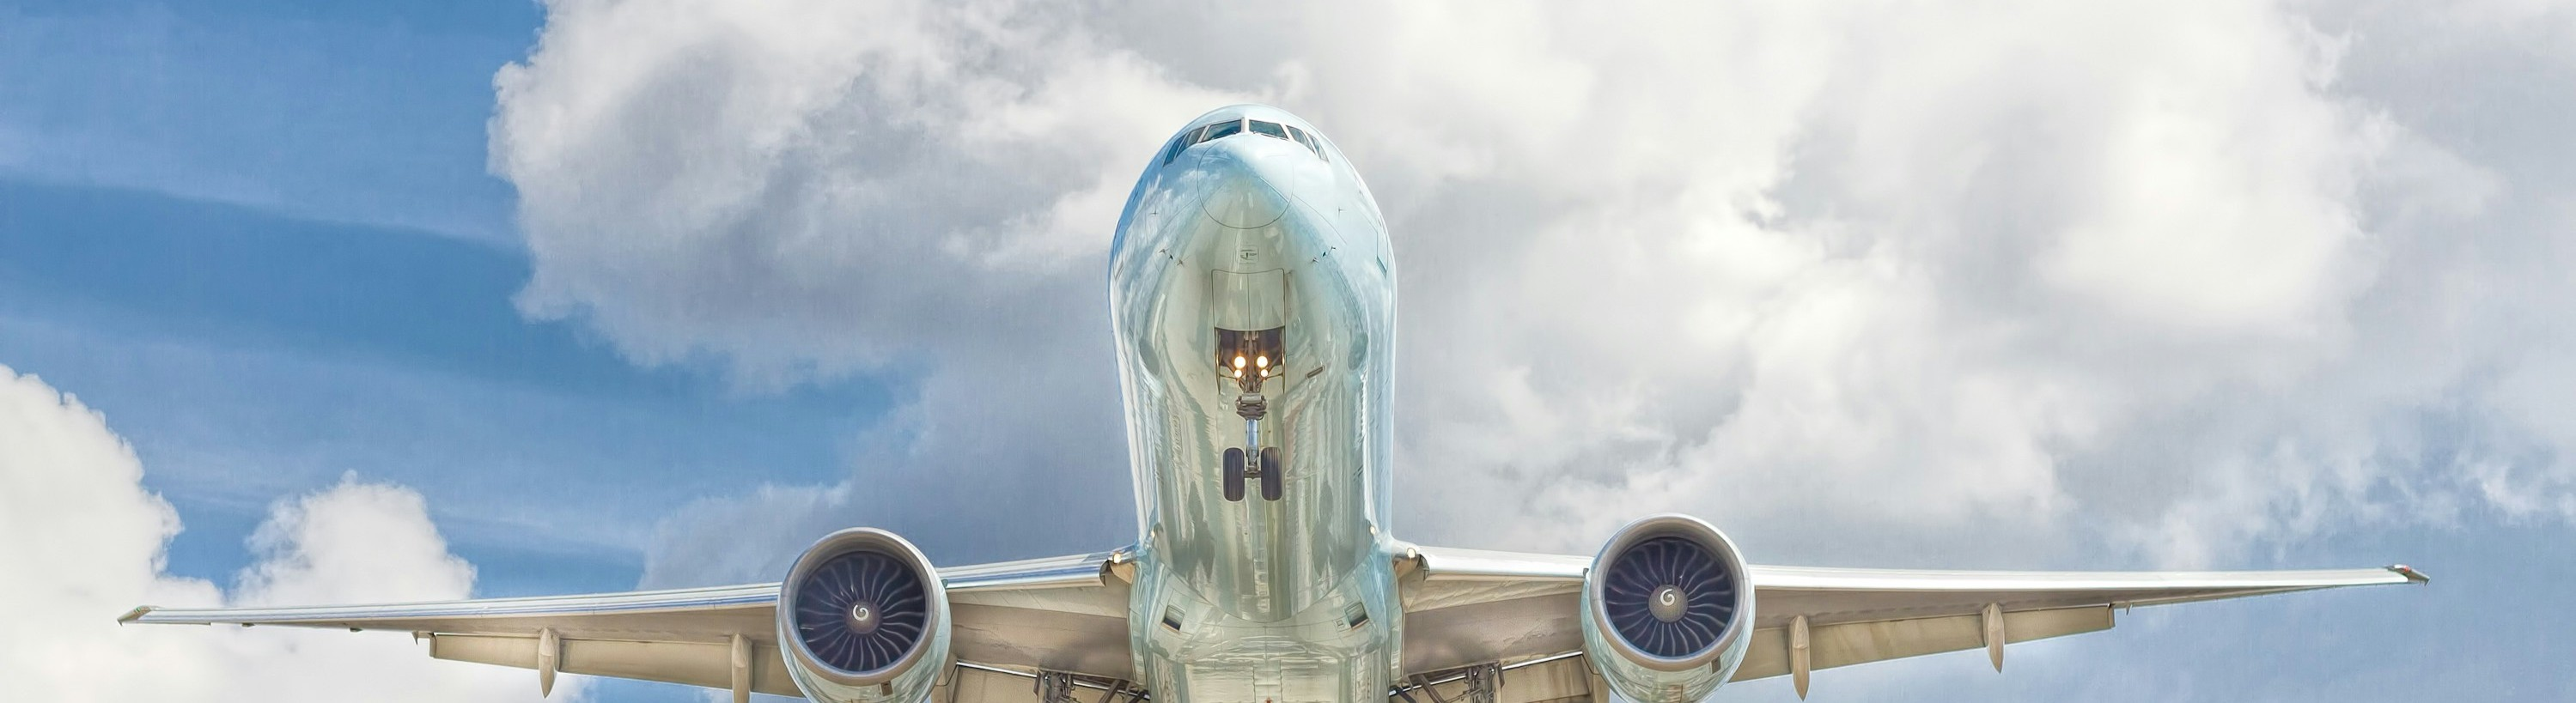

In [ ]:
#importing modules
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import opendatasets as od # importing kaggle api via opendatasets json notation
import statistics as st
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score


In [ ]:
od.download("https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dave8102
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction


100%|██████████| 4.16M/4.16M [00:00<00:00, 328MB/s]

# **Data Preprocessing**

In [ ]:
df = pd.read_csv("/content/flight-price-prediction/Clean_Dataset.csv") # the dataset has been successfully imported
print(df.describe())

          Unnamed: 0       duration      days_left          price
count  300153.000000  300153.000000  300153.000000  300153.000000
mean   150076.000000      12.221021      26.004751   20889.660523
std     86646.852011       7.191997      13.561004   22697.767366
min         0.000000       0.830000       1.000000    1105.000000
25%     75038.000000       6.830000      15.000000    4783.000000
50%    150076.000000      11.250000      26.000000    7425.000000
75%    225114.000000      16.170000      38.000000   42521.000000
max    300152.000000      49.830000      49.000000  123071.000000


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


**We're lucky there are no NAN values present in the dataset**

In [ ]:
duplicates = df[df.duplicated(subset='flight',keep=False)]
print(duplicates.describe())

          Unnamed: 0       duration      days_left          price
count  300132.000000  300132.000000  300132.000000  300132.000000
mean   150083.514444      12.220978      26.005254   20890.577569
std     86644.592430       7.192031      13.560533   22698.265554
min         0.000000       0.830000       1.000000    1105.000000
25%     75049.750000       6.830000      15.000000    4783.000000
50%    150085.500000      11.250000      26.000000    7425.000000
75%    225119.250000      16.170000      38.000000   42521.000000
max    300152.000000      49.830000      49.000000  123071.000000


the duplicated values don't make a clear difference the deviation was only 0.2 % which is negligible for the project

# **Exploratory Data Analysis**

In [ ]:
# Performing standard operations on the datasets
df.shape

(300153, 12)

In [ ]:
df.describe() # Statisitical analysis of the the dataset


,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


from matplotlib import pyplot as plt
_df_0['Unnamed: 0'].plot(kind='hist', bins=20, title='Unnamed: 0')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['duration'].plot(kind='hist', bins=20, title='duration')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['days_left'].plot(kind='hist', bins=20, title='days_left')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['price'].plot(kind='hist', bins=20, title='price')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_6.plot(kind='scatter', x='days_left', y='price', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_7['Unnamed: 0'].plot(kind='line', figsize=(8, 4), title='Unnamed: 0')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_8['duration'].plot(kind='line', figsize=(8, 4), title='duration')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_9['days_left'].plot(kind='line', figsize=(8, 4), title='days_left')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_10['price'].plot(kind='line', figsize=(8, 4), title='price')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
df.shape # the following dataset has 12 features and 300,153 rows

(300153, 12)

In [ ]:
df.isna().sum() # We are very lucky to have a clean dataset and no values are missing or Nan

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [ ]:
# Using univariate analysis to find extreme values

x = df.groupby('airline')[['price','days_left']].describe()
print(x)

              price                                                       \
              count          mean           std     min     25%      50%   
airline                                                                    
AirAsia     16098.0   4091.072742   2824.055172  1105.0  2361.0   3276.0   
Air_India   80892.0  23507.019112  20905.116909  1526.0  5623.0  11520.0   
GO_FIRST    23173.0   5652.007595   2513.865560  1105.0  4205.0   5336.0   
Indigo      43120.0   5324.216303   3268.894831  1105.0  3219.0   4453.0   
SpiceJet     9011.0   6179.278881   2999.630406  1106.0  4197.0   5654.0   
Vistara    127859.0  30396.536302  25637.159445  1714.0  6412.0  15543.0   

                             days_left                                         \
               75%       max     count       mean        std  min   25%   50%   
airline                                                                         
AirAsia     4589.0   31917.0   16098.0  27.735184  12.889223  1.0  17.0 

# There is a huge outlier in the prices of Air India for (ΣXi/n) = 23K which shows huge outlier as avg prices are 7-8k. Vistara being a premium brand can be tolerated


In [ ]:
#using percentile capping to cap prices to 87 percentile
threshold = df[df['airline'] == 'Air_India']['price'].quantile(0.87)
print(threshold)


52586.0


In [ ]:
a = df.loc[(df['airline']==' Air India ')&(df['price']>threshold),'price'] = threshold
print(a)

52586.0


# **Feature Engineering**


In [ ]:
df2 = df.rename(columns={
    "Unnamed: 0": "index"
})

print(df.columns)

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')


In [ ]:
df2.drop("index",axis='columns')

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
# Further optimizing features

In [ ]:
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None


In [ ]:
# Adding new column to classify the journey duration short or long
#looking at the duration we realized it's in hours
df2.rename({"duration":"duration_hrs"},axis=1)

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration_hrs,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


from matplotlib import pyplot as plt
_df_11['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_12['duration_hrs'].plot(kind='hist', bins=20, title='duration_hrs')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_13['days_left'].plot(kind='hist', bins=20, title='days_left')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_14['price'].plot(kind='hist', bins=20, title='price')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_35['source_city'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_35, x='index', y='source_city', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_36['departure_time'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_36, x='index', y='departure_time', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_37['stops'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_37, x='index', y='stops', inner='box', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
df2.shape

(300153, 12)

In [ ]:
x = df2.groupby('duration')[['arrival_time', 'destination_city']].mean()
print(x)

TypeError: agg function failed [how->mean,dtype->object]

WE CANNOT IMPLEMENT A NEW FEATURE SINCE THE COLUMNS 'arrival_time', 'destination_city' ARE obj64

<Axes: xlabel='days_left', ylabel='price'>

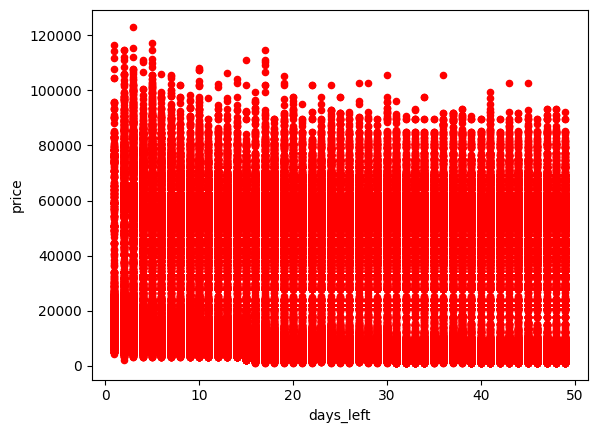

In [ ]:
#Visualisation
df2.plot(kind="scatter",x='days_left',y="price",color='red')

(0.0, 4.770505314687226)

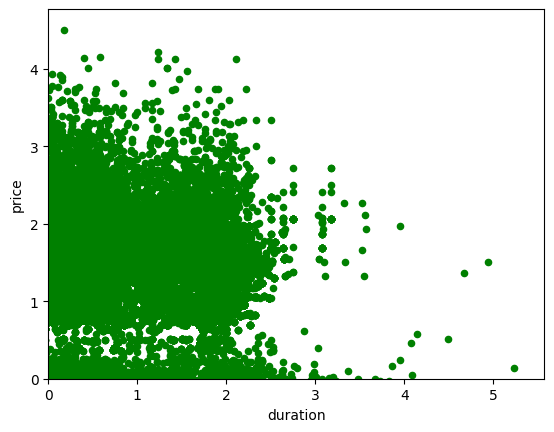

In [ ]:
#plotting scatter plot on duration to price
df2.plot(kind='scatter',x='duration',y='price',color='green')
plt.xlim(left=0)
plt.ylim(bottom=0)

# STANDARIZING THE DATASET



In [ ]:
# Determing the numerical features
print(df2.info())
# We will standarize the duration days left and price features

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB
None


In [ ]:
scaler_cols = ['duration','days_left','price']
scaler = StandardScaler()
df2[scaler_cols] = scaler.fit_transform(df2[scaler_cols])



print(df2[['duration','days_left','price']])



        duration  days_left     price
0      -1.397531  -1.843875 -0.658068
1      -1.375284  -1.843875 -0.658068
2      -1.397531  -1.843875 -0.657936
3      -1.386407  -1.843875 -0.657980
4      -1.375284  -1.843875 -0.657980
...          ...        ...       ...
300148 -0.297695   1.695692  2.131285
300149 -0.250421   1.695692  2.476694
300150  0.223718   1.695692  2.564545
300151 -0.308819   1.695692  2.674071
300152 -0.297695   1.695692  2.674071

[300153 rows x 3 columns]


In [ ]:
print(df2.head())
# Checking the validity

   index   airline   flight source_city departure_time stops   arrival_time  \
0      0  SpiceJet  SG-8709       Delhi        Evening  zero          Night   
1      1  SpiceJet  SG-8157       Delhi  Early_Morning  zero        Morning   
2      2   AirAsia   I5-764       Delhi  Early_Morning  zero  Early_Morning   
3      3   Vistara   UK-995       Delhi        Morning  zero      Afternoon   
4      4   Vistara   UK-963       Delhi        Morning  zero        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy      2.17          1   5953  
1           Mumbai  Economy      2.33          1   5953  
2           Mumbai  Economy      2.17          1   5956  
3           Mumbai  Economy      2.25          1   5955  
4           Mumbai  Economy      2.33          1   5955  


# **Splitting the Data Set**

In [ ]:
y = df2['price'] #predication target
X = df2.drop(['flight', 'price'], axis=1)

# Convert categorical features into dummy variables
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (240122, 31)
Shape of X_test: (60031, 31)
Shape of y_train: (240122,)
Shape of y_test: (60031,)


In [ ]:
# Model selection using
rf_regressor = RandomForestRegressor(random_state=33)

### For enhanced Prediciton we will use random forest regressor

In [ ]:
#Training the random forest regressor
rf_regressor.fit(X_train,y_train)


RandomForestRegressor(random_state=33)

In [ ]:
y_pred = rf_regressor.predict(X_test)
print(y_pred[:10])

[-0.59884935  2.16508966 -0.64729076  1.74415769 -0.64089056 -0.63111072
  0.12989579 -0.75049139  0.8567447   2.09067649]


# Inverse transform predictions and actual values
# Get mean and std for 'price' from the scaler


## Inverse Transform Predictions and Actual Values




In [ ]:
price_mean = scaler.mean_[scaler_cols.index('price')]
price_std = scaler.scale_[scaler_cols.index('price')]

print(f"Mean of 'price' feature: {price_mean}")
print(f"Standard deviation of 'price' feature: {price_std}")

Mean of 'price' feature: 20889.660523133203
Standard deviation of 'price' feature: 22697.729555713966


In [ ]:
y_pred_original = (y_pred * price_std) + price_mean
y_test_original = (y_test * price_std) + price_mean

print("Inverse transformation completed.")
print(f"First 5 inverse-transformed predicted prices: {y_pred_original[:5]}")
print(f"First 5 inverse-transformed actual prices: {y_test_original.iloc[:5].values}")

Inverse transformation completed.
First 5 inverse-transformed predicted prices: [ 7297.14 70032.28  6197.63 60478.08  6342.9 ]
First 5 inverse-transformed actual prices: [ 7366. 64831.  6195. 60160.  6578.]


# **Evaluation**

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_original, y_pred_original)
mse = mean_squared_error(y_test_original, y_pred_original)
r2 = r2_score(y_test_original, y_pred_original)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

print("\nFirst 10 Actual vs. Predicted Prices (Inverse Transformed):")
for i in range(10):
    print(f"Actual: {y_test_original.iloc[i]:.2f}, Predicted: {y_pred_original[i]:.2f}")

Mean Absolute Error (MAE): 948.51
Mean Squared Error (MSE): 6184507.29
R-squared (R2) Score: 0.99

First 10 Actual vs. Predicted Prices (Inverse Transformed):
Actual: 7366.00, Predicted: 7297.14
Actual: 64831.00, Predicted: 70032.28
Actual: 6195.00, Predicted: 6197.63
Actual: 60160.00, Predicted: 60478.08
Actual: 6578.00, Predicted: 6342.90
Actual: 4555.00, Predicted: 6564.88
Actual: 23838.00, Predicted: 23838.00
Actual: 3860.00, Predicted: 3855.21
Actual: 32230.00, Predicted: 40335.82
Actual: 76841.00, Predicted: 68343.27
